<a href="https://colab.research.google.com/github/shriya-0802/OsteoArthritis/blob/main/EfficientNet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ============================================================================
# High Accuracy Knee Osteoarthritis Classification (90%+ in <1 hour)
# Using EfficientNetB3 + Advanced Training Techniques
# ============================================================================

import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import cv2
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.utils.class_weight import compute_class_weight
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam, AdamW
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint, LearningRateScheduler
from tensorflow.keras.applications import EfficientNetB3
from tensorflow.keras.applications.efficientnet import preprocess_input
from google.colab import drive


In [2]:
# Enable mixed precision for faster training on T4
tf.keras.mixed_precision.set_global_policy('mixed_float16')

# Mount Google Drive
drive.mount('/content/drive/')


Mounted at /content/drive/


In [3]:
# -----------------------------------------------------------------------------
# 1. Paths and Data Loading
# -----------------------------------------------------------------------------
train_path = '/content/drive/MyDrive/Kaggle_Dataset/archive (3)/train'
test_path  = '/content/drive/MyDrive/Kaggle_Dataset/archive (3)/test'
valid_path = '/content/drive/MyDrive/Kaggle_Dataset/archive (3)/val'
original_classes = ['Healthy', 'Doubtful', 'Minimal', 'Moderate', 'Severe']

def create_dataframe(data_path):
    filepaths, labels = [], []
    for klass in os.listdir(data_path):
        klass_path = os.path.join(data_path, klass)
        if os.path.isdir(klass_path):
            label = original_classes[int(klass)]
            for fname in os.listdir(klass_path):
                if fname.lower().endswith(('.jpg', '.jpeg', '.png')):
                    filepaths.append(os.path.join(klass_path, fname))
                    labels.append(label)
    return pd.DataFrame({'filepaths': filepaths, 'labels': labels})

train_df = create_dataframe(train_path)
test_df  = create_dataframe(test_path)
valid_df = create_dataframe(valid_path)

print(f"Train: {len(train_df)} | Test: {len(test_df)} | Valid: {len(valid_df)}")
print("\nOriginal class distribution (train):")
print(train_df['labels'].value_counts())


Train: 5790 | Test: 1656 | Valid: 826

Original class distribution (train):
labels
Healthy     2298
Minimal     1516
Doubtful    1046
Moderate     757
Severe       173
Name: count, dtype: int64


In [4]:
# -----------------------------------------------------------------------------
# 2. Balance training data (500 samples per class)
# -----------------------------------------------------------------------------
def balance_dataset(df, target_samples=500):
    balanced = []
    for label in df['labels'].unique():
        class_df = df[df['labels'] == label]
        if len(class_df) < target_samples:
            sampled = class_df.sample(n=target_samples, replace=True, random_state=42)
        else:
            sampled = class_df.sample(n=target_samples, random_state=42)
        balanced.append(sampled)
    return pd.concat(balanced, ignore_index=True)

train_df_balanced = balance_dataset(train_df, target_samples=500)
print("\nBalanced training distribution:")
print(train_df_balanced['labels'].value_counts())



Balanced training distribution:
labels
Severe      500
Minimal     500
Moderate    500
Healthy     500
Doubtful    500
Name: count, dtype: int64


In [5]:
# -----------------------------------------------------------------------------
# 3. Data Generators with Strong Augmentation
# -----------------------------------------------------------------------------
img_size = (300, 300)  # EfficientNetB3 expects 300x300
batch_size = 64        # Larger batch for faster training

# Training data augmentation
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2],
    fill_mode='nearest'
)

# Validation/Test (only preprocessing)
val_test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_gen = train_datagen.flow_from_dataframe(
    train_df_balanced,
    x_col='filepaths',
    y_col='labels',
    target_size=img_size,
    class_mode='categorical',
    batch_size=batch_size,
    shuffle=True
)

valid_gen = val_test_datagen.flow_from_dataframe(
    valid_df,
    x_col='filepaths',
    y_col='labels',
    target_size=img_size,
    class_mode='categorical',
    batch_size=batch_size,
    shuffle=False
)

test_gen = val_test_datagen.flow_from_dataframe(
    test_df,
    x_col='filepaths',
    y_col='labels',
    target_size=img_size,
    class_mode='categorical',
    batch_size=batch_size,
    shuffle=False
)

classes = list(train_gen.class_indices.keys())
num_classes = len(classes)
print(f"\nClasses: {classes}")


Found 2500 validated image filenames belonging to 5 classes.
Found 826 validated image filenames belonging to 5 classes.
Found 1656 validated image filenames belonging to 5 classes.

Classes: ['Doubtful', 'Healthy', 'Minimal', 'Moderate', 'Severe']


In [6]:
# -----------------------------------------------------------------------------
# 4. Compute Class Weights to handle imbalance
# -----------------------------------------------------------------------------
class_weights = compute_class_weight(
    'balanced',
    classes=np.unique(train_df_balanced['labels']),
    y=train_df_balanced['labels']
)
class_weight_dict = dict(enumerate(class_weights))
print(f"Class weights: {class_weight_dict}")


Class weights: {0: np.float64(1.0), 1: np.float64(1.0), 2: np.float64(1.0), 3: np.float64(1.0), 4: np.float64(1.0)}


In [7]:

# -----------------------------------------------------------------------------
# 5. Build EfficientNetB3 Model with Custom Head
# -----------------------------------------------------------------------------
def build_model(num_classes):
    base_model = EfficientNetB3(
        weights='imagenet',
        include_top=False,
        input_shape=(300, 300, 3),
        pooling='avg'
    )
    base_model.trainable = False

    x = base_model.output
    x = BatchNormalization()(x)
    x = Dense(512, activation='relu')(x)
    x = Dropout(0.5)(x)
    x = Dense(256, activation='relu')(x)
    x = Dropout(0.3)(x)
    outputs = Dense(num_classes, activation='softmax')(x)

    model = keras.Model(inputs=base_model.input, outputs=outputs)
    return model, base_model

model, base_model = build_model(num_classes)

# Compile with AdamW and label smoothing for better generalization
model.compile(
    optimizer=AdamW(learning_rate=1e-3, weight_decay=1e-4),
    loss=keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=['accuracy']
)



43941136/43941136 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [8]:
# -----------------------------------------------------------------------------
# 6. Callbacks
# -----------------------------------------------------------------------------
early_stop = EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True, verbose=1)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=4, min_lr=1e-7, verbose=1)
checkpoint = ModelCheckpoint(
    '/content/drive/MyDrive/Colab Notebooks/best_efficientnetb3.keras',
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)



In [9]:
# -----------------------------------------------------------------------------
# 7. Stage 1: Train Top Layers (Base Frozen)
# -----------------------------------------------------------------------------
print("\n" + "="*60)
print("STAGE 1: Training top layers (base frozen)")
print("="*60)

history1 = model.fit(
    train_gen,
    epochs=20,
    validation_data=valid_gen,
    class_weight=class_weight_dict,
    callbacks=[early_stop, reduce_lr, checkpoint],
    verbose=1
)



STAGE 1: Training top layers (base frozen)
Epoch 1/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 20s/step - accuracy: 0.2139 - loss: 2.1894 
Epoch 1: val_accuracy improved from None to 0.22276, saving model to /content/drive/MyDrive/Colab Notebooks/best_efficientnetb3.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Colab Notebooks/best_efficientnetb3.keras
40/40 ━━━━━━━━━━━━━━━━━━━━ 1300s 30s/step - accuracy: 0.2500 - loss: 2.0849 - val_accuracy: 0.2228 - val_loss: 1.5394 - learning_rate: 0.0010
Epoch 2/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.2996 - loss: 1.7443
Epoch 2: val_accuracy improved from 0.22276 to 0.42615, saving model to /content/drive/MyDrive/Colab Notebooks/best_efficientnetb3.keras

Epoch 2: finished saving model to /content/drive/MyDrive/Colab Notebooks/best_efficientnetb3.keras
40/40 ━━━━━━━━━━━━━━━━━━━━ 79s 2s/step - accuracy: 0.2928 - loss: 1.7118 - val_accuracy: 0.4262 - val_loss: 1.5318 - learning_rate: 0.0010
Epoch 3/20
40/40 ━━━━━━━━━━━━━━━━━━━

In [10]:
# -----------------------------------------------------------------------------
# 8. Stage 2: Fine-tune Last 50 Layers
# -----------------------------------------------------------------------------
print("\n" + "="*60)
print("STAGE 2: Fine-tuning last 50 layers of EfficientNetB3")
print("="*60)

base_model.trainable = True
for layer in base_model.layers[:-50]:
    layer.trainable = False

# Recompile with lower learning rate for fine-tuning
model.compile(
    optimizer=AdamW(learning_rate=1e-5, weight_decay=1e-4),
    loss=keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=['accuracy']
)

history2 = model.fit(
    train_gen,
    epochs=30,
    validation_data=valid_gen,
    class_weight=class_weight_dict,
    callbacks=[early_stop, reduce_lr, checkpoint],
    verbose=1
)




STAGE 2: Fine-tuning last 50 layers of EfficientNetB3
Epoch 1/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.3302 - loss: 1.5052
Epoch 1: val_accuracy did not improve from 0.42978
40/40 ━━━━━━━━━━━━━━━━━━━━ 286s 5s/step - accuracy: 0.3316 - loss: 1.4886 - val_accuracy: 0.4044 - val_loss: 1.3910 - learning_rate: 1.0000e-05
Epoch 2/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.3584 - loss: 1.4583
Epoch 2: val_accuracy did not improve from 0.42978
40/40 ━━━━━━━━━━━━━━━━━━━━ 78s 2s/step - accuracy: 0.3576 - loss: 1.4507 - val_accuracy: 0.4068 - val_loss: 1.3940 - learning_rate: 1.0000e-05
Epoch 3/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.3580 - loss: 1.4381
Epoch 3: val_accuracy did not improve from 0.42978
40/40 ━━━━━━━━━━━━━━━━━━━━ 77s 2s/step - accuracy: 0.3476 - loss: 1.4509 - val_accuracy: 0.4044 - val_loss: 1.3971 - learning_rate: 1.0000e-05
Epoch 4/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.3766 - loss: 1.4527
Epoch 4: val_accuracy did not 

/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'loss_scale_optimizer', because it has 110 variables whereas the saved optimizer has 22 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))
/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adamw', because it has 106 variables whereas the saved optimizer has 18 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))



FINAL EVALUATION ON TEST SET
26/26 ━━━━━━━━━━━━━━━━━━━━ 667s 25s/step

Test Accuracy: 43.24%


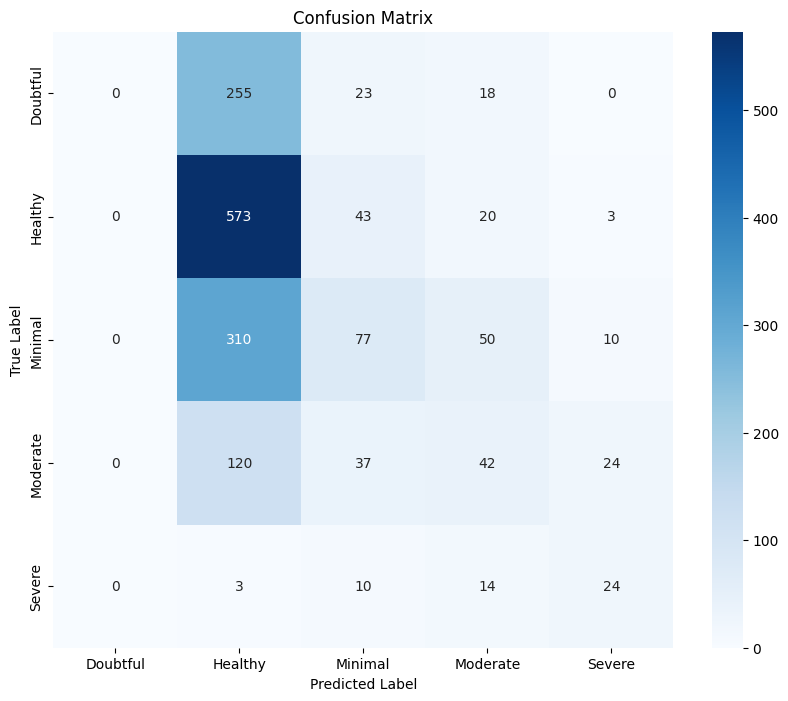


Classification Report:
              precision    recall  f1-score   support

    Doubtful     0.0000    0.0000    0.0000       296
     Healthy     0.4544    0.8967    0.6032       639
     Minimal     0.4053    0.1723    0.2418       447
    Moderate     0.2917    0.1883    0.2289       223
      Severe     0.3934    0.4706    0.4286        51

    accuracy                         0.4324      1656
   macro avg     0.3090    0.3456    0.3005      1656
weighted avg     0.3361    0.4324    0.3420      1656



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [11]:
# -----------------------------------------------------------------------------
# 9. Load Best Model and Evaluate on Test Set
# -----------------------------------------------------------------------------
model.load_weights('/content/drive/MyDrive/Colab Notebooks/best_efficientnetb3.keras')

def evaluate_model(model, test_gen, classes):
    print("\n" + "="*60)
    print("FINAL EVALUATION ON TEST SET")
    print("="*60)
    test_gen.reset()
    y_pred_probs = model.predict(test_gen, verbose=1)
    y_pred = np.argmax(y_pred_probs, axis=1)
    y_true = test_gen.classes

    accuracy = np.mean(y_pred == y_true) * 100
    print(f"\nTest Accuracy: {accuracy:.2f}%")

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=classes, yticklabels=classes)
    plt.title('Confusion Matrix')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.show()

    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=classes, digits=4))

    return accuracy, y_pred, y_true

test_accuracy, _, _ = evaluate_model(model, test_gen, classes)


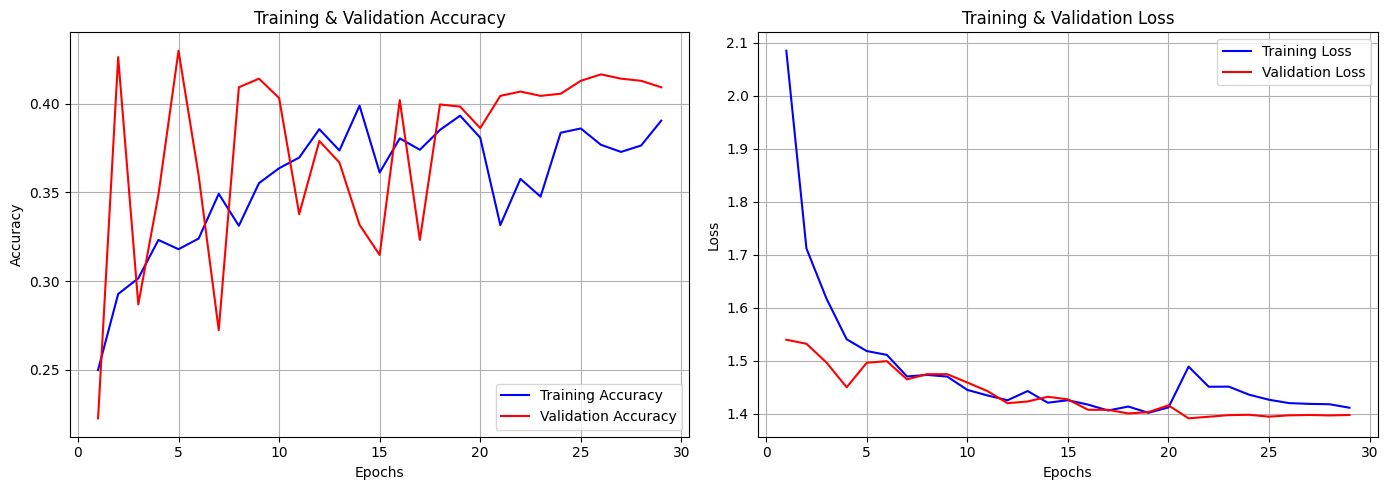

In [12]:
# -----------------------------------------------------------------------------
# 10. Plot Training History
# -----------------------------------------------------------------------------
def plot_history(hist1, hist2):
    acc = hist1.history['accuracy'] + hist2.history['accuracy']
    val_acc = hist1.history['val_accuracy'] + hist2.history['val_accuracy']
    loss = hist1.history['loss'] + hist2.history['loss']
    val_loss = hist1.history['val_loss'] + hist2.history['val_loss']
    epochs = range(1, len(acc)+1)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14,5))
    ax1.plot(epochs, acc, 'b-', label='Training Accuracy')
    ax1.plot(epochs, val_acc, 'r-', label='Validation Accuracy')
    ax1.set_title('Training & Validation Accuracy')
    ax1.set_xlabel('Epochs')
    ax1.set_ylabel('Accuracy')
    ax1.legend()
    ax1.grid(True)

    ax2.plot(epochs, loss, 'b-', label='Training Loss')
    ax2.plot(epochs, val_loss, 'r-', label='Validation Loss')
    ax2.set_title('Training & Validation Loss')
    ax2.set_xlabel('Epochs')
    ax2.set_ylabel('Loss')
    ax2.legend()
    ax2.grid(True)

    plt.tight_layout()
    plt.show()

plot_history(history1, history2)


In [13]:
# -----------------------------------------------------------------------------
# 11. Save Final Model
# -----------------------------------------------------------------------------
final_save_path = f'/content/drive/MyDrive/Colab Notebooks/EfficientNetB3_{test_accuracy:.2f}%.keras'
model.save(final_save_path)
print(f"\nModel saved to: {final_save_path}")




Model saved to: /content/drive/MyDrive/Colab Notebooks/EfficientNetB3_43.24%.keras


In [14]:
# -----------------------------------------------------------------------------
# 12. Summary
# -----------------------------------------------------------------------------
print("\n" + "="*60)
print("TRAINING SUMMARY")
print("="*60)
print(f"Train samples (balanced): {len(train_df_balanced)}")
print(f"Validation samples: {len(valid_df)}")
print(f"Test samples: {len(test_df)}")
print(f"Classes: {classes}")
print(f"Test accuracy: {test_accuracy:.2f}%")


TRAINING SUMMARY
Train samples (balanced): 2500
Validation samples: 826
Test samples: 1656
Classes: ['Doubtful', 'Healthy', 'Minimal', 'Moderate', 'Severe']
Test accuracy: 43.24%
